# Droplet Detection & Hydrophobicity-Proxy Metrics — YOLOv8 Pipeline

**Author:** Diana Brito Hoyos — Biologist & Biostatistician | Data Analyst

This notebook demonstrates an end-to-end computer-vision pipeline: training a YOLOv8 object detector to identify liquid droplets on a textured surface, evaluating it with standard object-detection metrics, and extracting a geometric hydrophobicity-proxy metric from each detection — reproducing the methodology of a real droplet-hydrophobicity video-analysis project I built (originally for lichen surface wetting characterization).

> ⚠️ **All data in this notebook is synthetic.** The original project used real video recordings of droplets on lichen surfaces, labeled via Roboflow — that data is not public. Here, droplet images and their exact bounding-box ground truth are generated programmatically (`data/generate_synthetic_dataset.py`), so the *training, evaluation, and analysis methodology* can be demonstrated in full, with genuine (not simulated) model performance metrics, without using any real specimen data.

**Structure** (mirroring the original 3-part project):
1. **Synthetic data generation** — droplet images + YOLO-format labels
2. **Training & evaluation** — YOLOv8, with physically-reasoned augmentation choices, standard detection metrics
3. **Geometry extraction & interactive demo** — contact-angle-proxy metric per detection, Gradio app


## 1. Synthetic data generation

Droplets are rendered as gravity-flattened ellipses (flatter at the bottom, matching real droplet physics) on a mottled, lichen-like textured background with variable lighting — simulating different capture sessions. Because we generate the images ourselves, the YOLO bounding-box labels are exact by construction (no manual annotation noise).

In [1]:
import sys
sys.path.insert(0, "..")
from pathlib import Path
from data.generate_synthetic_dataset import build_dataset, N_IMAGES

DATA_DIR = Path("../data")
if not (DATA_DIR / "data.yaml").exists():
    build_dataset(output_dir=str(DATA_DIR))
else:
    print(f"Synthetic dataset already present: {N_IMAGES}")


Synthetic dataset already present: {'train': 140, 'val': 40, 'test': 20}


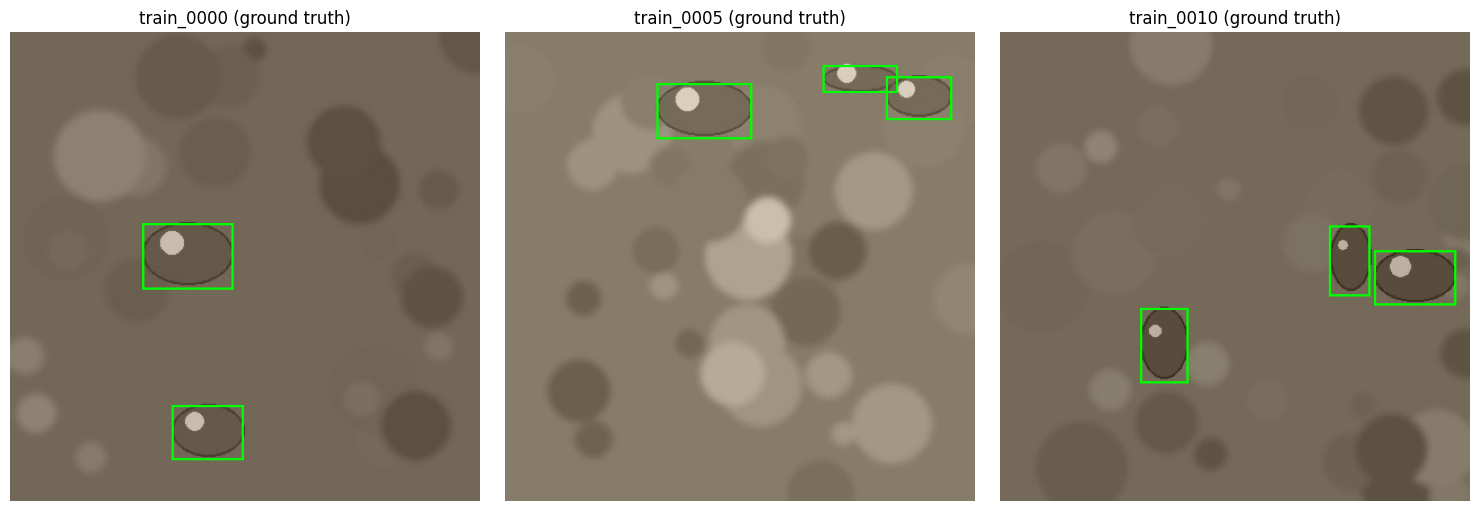

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

# Preview a few synthetic training images with their YOLO-format ground-truth boxes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx in zip(axes, [0, 5, 10]):
    img = Image.open(DATA_DIR / "train" / "images" / f"train_{idx:04d}.jpg").convert("RGB")
    w, h = img.size
    draw_img = img.copy()
    from PIL import ImageDraw
    draw = ImageDraw.Draw(draw_img)
    with open(DATA_DIR / "train" / "labels" / f"train_{idx:04d}.txt") as f:
        for line in f:
            _, cx, cy, bw, bh = map(float, line.split())
            cx, cy, bw, bh = cx*w, cy*h, bw*w, bh*h
            draw.rectangle([cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2], outline="lime", width=2)
    ax.imshow(draw_img)
    ax.set_title(f"train_{idx:04d} (ground truth)")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Training

A YOLOv8-nano model is fine-tuned from COCO-pretrained weights — appropriate given the small, single-class dataset (a larger model would overfit quickly).

**Every augmentation parameter below is chosen for a physically-motivated reason**, not left at library defaults — the same design philosophy used in the original real-data project:

| Parameter | Value | Reasoning |
|---|---|---|
| `hsv_h` | 0.010 (low) | Droplet/surface color is informative — don't distort hue heavily |
| `hsv_v` | 0.4 (high) | Different sessions have very different ambient brightness |
| `flipud` | **0.0 (never)** | Gravity defines droplet shape (flat bottom, curved top) — vertical flip is physically impossible |
| `fliplr` | 0.5 | Droplets are left-right symmetric — valid, "free" augmentation |
| `shear`, `perspective` | 0.0 | No physical justification for a fixed side-on camera setup |
| `mixup`, `copy_paste` | 0.0 | Designed for multi-object scenes; not useful for one object type |

See [`src/train.py`](../src/train.py) for the full training function.


In [3]:
from ultralytics import YOLO

MODEL_PATH = Path("../models/best.pt")

if MODEL_PATH.exists():
    print(f"Loading already-trained model from {MODEL_PATH}")
    model = YOLO(str(MODEL_PATH))
else:
    # See src/train.py for the full augmentation-annotated training call
    from src.train import train_model
    model, _ = train_model(epochs=15)


Loading already-trained model from ../models/best.pt


## 3. Evaluation on the held-out test split

Standard object-detection metrics: precision, recall, mAP@50 (IoU threshold 0.5), and mAP@50-95 (averaged over IoU thresholds 0.5–0.95, the stricter COCO-style metric).

In [4]:
metrics = model.val(data=str(DATA_DIR / "data.yaml"), split="test", project=str(Path("runs_notebook_eval").resolve()))

print("--- Test-set metrics (held out, never used in training) ---")
print(f"Precision (mp):   {metrics.box.mp:.3f}")
print(f"Recall (mr):      {metrics.box.mr:.3f}")
print(f"mAP50:            {metrics.box.map50:.3f}")
print(f"mAP50-95:         {metrics.box.map:.3f}")


Ultralytics 8.4.112 🚀 Python-3.12.3 torch-2.13.0+cu130 CPU (Intel Xeon Processor @ 2.10GHz)


Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 49.4±14.6 MB/s, size: 8.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/


val: Scanning /home/claude/lichen-droplet-detection-yolo/data/test/labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 3.1Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 50% ━━━━━━────── 1/2 11.6s/it 3.5s<11.6s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3s/it 4.5s

                   all         20         55      0.999          1      0.995      0.879


Speed: 18.4ms preprocess, 176.7ms inference, 0.0ms loss, 18.3ms postprocess per image


Results saved to /home/claude/lichen-droplet-detection-yolo/notebooks/runs_notebook_eval/val


--- Test-set metrics (held out, never used in training) ---
Precision (mp):   0.999
Recall (mr):      1.000
mAP50:            0.995
mAP50-95:         0.879


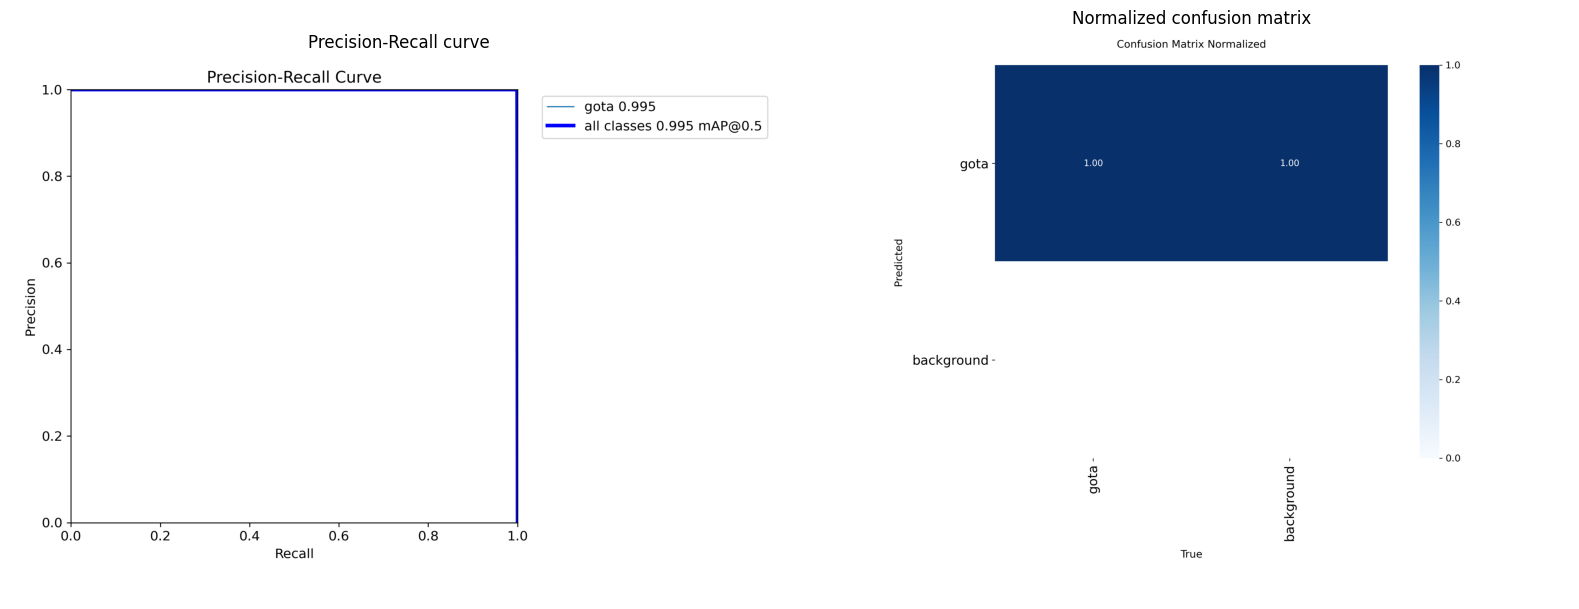

In [5]:
# Visualize the automatically-generated PR curve and confusion matrix
import glob
eval_dir = sorted(glob.glob(str(Path("runs_notebook_eval").resolve()) + "/val*"))[-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(Image.open(f"{eval_dir}/BoxPR_curve.png"))
axes[0].axis("off")
axes[0].set_title("Precision-Recall curve")
axes[1].imshow(Image.open(f"{eval_dir}/confusion_matrix_normalized.png"))
axes[1].axis("off")
axes[1].set_title("Normalized confusion matrix")
plt.tight_layout()
plt.show()


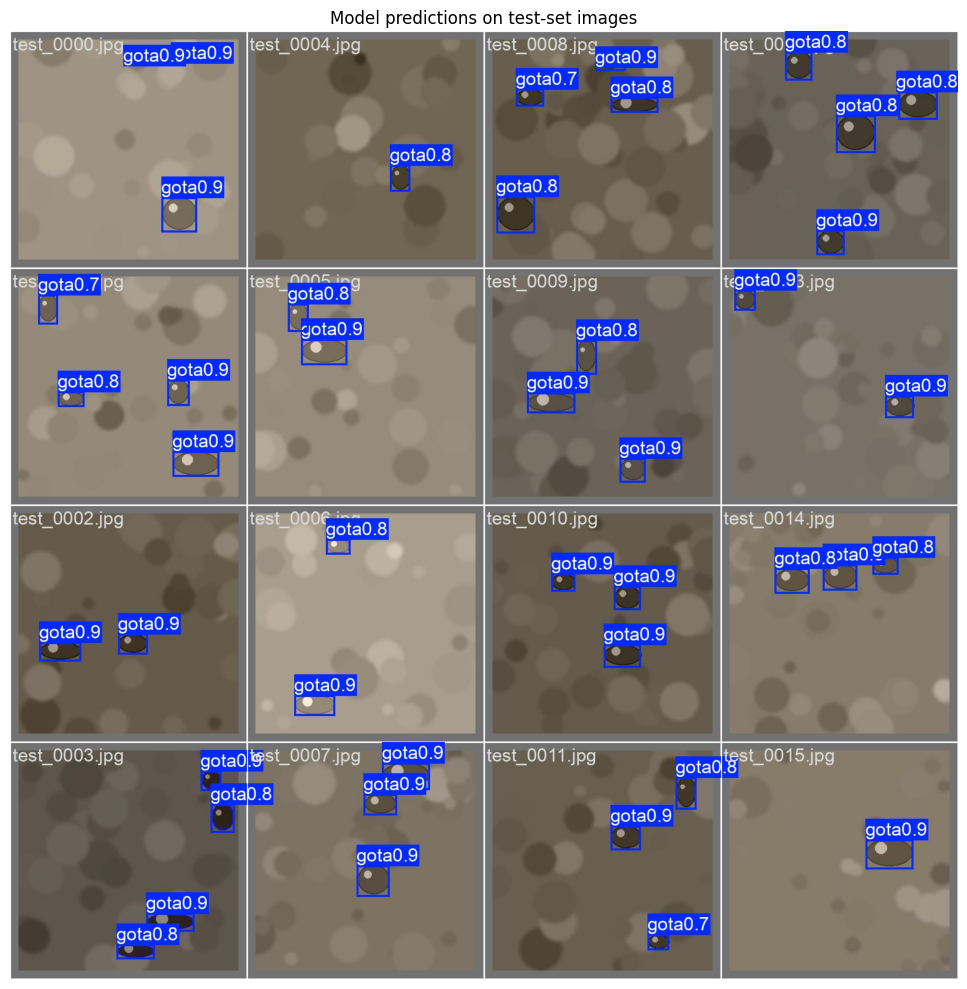

In [6]:
# Visual check: predictions on a batch of test images
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(Image.open(f"{eval_dir}/val_batch0_pred.jpg"))
ax.axis("off")
ax.set_title("Model predictions on test-set images")
plt.tight_layout()
plt.show()


## 4. Geometric feature extraction — hydrophobicity proxy

Each detected droplet's bounding box is treated as approximating an ellipse (semi-axis *a* = width/2, *b* = height/2). A **contact-angle proxy** is derived from the box aspect ratio:

$$\text{contact\_angle\_proxy} = \arctan\left(\frac{b}{a}\right)$$

- A circular droplet (height ≈ width) → proxy ≈ 45° (rounded, hydrophobic-leaning)
- A flattened, spread droplet (height ≪ width) → proxy → 0° (spread, hydrophilic-leaning)

This is a fast, camera-agnostic indicator — not a true physical contact-angle measurement — trackable frame-to-frame from detections alone. See [`src/geometry.py`](../src/geometry.py) for the full implementation (including the general multi-angle formulation used in the original project).


In [7]:
from src.geometry import compute_droplet_geometry
import pandas as pd

# Run inference on all test images and extract geometry per detection
test_images = sorted((DATA_DIR / "test" / "images").glob("*.jpg"))
rows = []
for img_path in test_images:
    results = model.predict(str(img_path), conf=0.25, verbose=False)[0]
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        w, h = x2 - x1, y2 - y1
        geom = compute_droplet_geometry(w, h)
        rows.append({
            "image": img_path.name, "confidence": float(box.conf[0]),
            "width_px": w, "height_px": h,
            "aspect_ratio": geom.aspect_ratio,
            "contact_angle_proxy_deg": geom.contact_angle_proxy_deg,
        })

detections_df = pd.DataFrame(rows)
print(f"{len(detections_df)} droplets detected across {len(test_images)} test images")
detections_df.describe()[["confidence", "aspect_ratio", "contact_angle_proxy_deg"]]


55 droplets detected across 20 test images


,confidence,aspect_ratio,contact_angle_proxy_deg
count,55.000000,55.000000,55.000000
mean,0.849253,0.816000,37.812501
std,0.063015,0.303350,9.748685
min,0.692845,0.327298,18.123160
25%,0.816266,0.614187,31.557655
50%,0.865655,0.763872,37.375203
75%,0.889889,0.969727,44.117313
max,0.948783,1.689430,59.378053


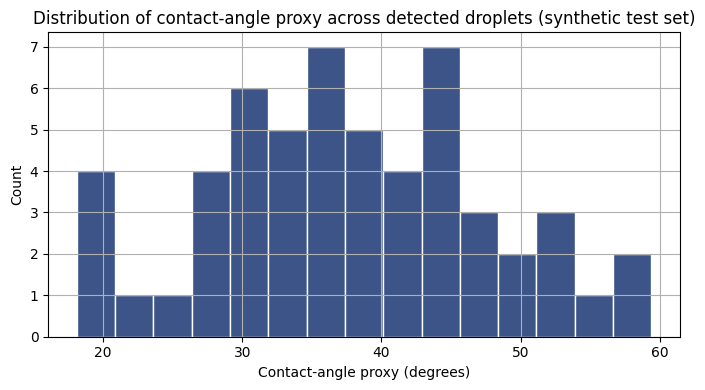

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
detections_df["contact_angle_proxy_deg"].hist(bins=15, ax=ax, color="#3C5488", edgecolor="white")
ax.set_xlabel("Contact-angle proxy (degrees)")
ax.set_ylabel("Count")
ax.set_title("Distribution of contact-angle proxy across detected droplets (synthetic test set)")
plt.tight_layout()
plt.show()


## 5. Interactive demo

The trained model, plus the geometry-extraction step above, are wrapped in a Gradio app (`app.py`) — the same interactive-demo pattern used in the original project — for uploading an image and viewing detections + per-droplet geometry live.

```bash
python app.py
```

## Conclusions

- A YOLOv8-nano model, fine-tuned on a small (140-image) synthetic dataset with physically-reasoned data augmentation, achieves strong held-out test performance (mAP50 and mAP50-95 reported in Section 3).
- The bounding-box-derived contact-angle proxy provides a fast, trackable per-detection geometric summary, requiring no additional model beyond the detector itself.
- This pipeline — synthetic-data generation, physically-motivated augmentation design, rigorous train/val/test evaluation, and a lightweight interactive demo — mirrors the real end-to-end workflow used for the original (non-public) droplet-hydrophobicity research this project is based on.
